In [2]:
import os
import csv
import json
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

import rasterio
import geopandas as gpd
from shapely.geometry import Point

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
pip install geopandas


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Early stopping class

In [4]:
class EarlyStopping:
    def __init__(self, patience=30, delta=0.0001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# Loss Functions

In [5]:
# class QuantileLoss(nn.Module):
#     def __init__(self, quantile=0.9):
#         super().__init__()
#         self.quantile = quantile

#     def forward(self, pred, target):
#         error = target - pred
#         return torch.max(self.quantile * error, (self.quantile - 1) * error).mean()

In [6]:
class WeibullWeightedMSELoss(nn.Module):
    def __init__(self, kappa=28.0, alpha=2.75, eps=1e-6):
        super().__init__()
        self.kappa = kappa
        self.alpha = alpha
        self.eps = eps

    def forward(self, preds, targets):
        k, a = self.kappa, self.alpha
        pdf = (k/a) * ((targets/a)**(k-1)) * torch.exp(-(targets/a)**k)
        weights = 1.0 / (pdf + self.eps)
        weights = weights / weights.mean()
        return (weights * (preds - targets)**2).mean()

In [7]:
class WeightedMSELoss(nn.Module):
    def __init__(self, threshold=0.2, factor=25):
        super().__init__()
        self.threshold = threshold
        self.factor = factor

    def forward(self, predictions, targets):
        weights = torch.where(
            targets > self.threshold,
            torch.ones_like(targets) * self.factor,
            torch.ones_like(targets)
        )
        return (weights * (predictions - targets) ** 2).mean()

In [8]:
class AsymmetricMSELoss(nn.Module):
    def __init__(self, under_penalty=5.0):
        super().__init__()
        self.under_penalty = under_penalty
    
    def forward(self, pred, target):
        error = pred - target
        loss = torch.where(error < 0,
                          self.under_penalty * error ** 2,  # Under: 5Ã— penalty
                          error ** 2)                        # Over: 1Ã— penalty
        return loss.mean()

In [9]:
class ContinuousWeightedMSELoss(nn.Module):
    def __init__(self, base=1.0, scale=20.0):
        super().__init__()
        self.base = base
        self.scale = scale

    def forward(self, preds, targets):
        weights = self.base + self.scale * targets
        return (weights * (preds - targets) ** 2).mean()

In [10]:
# class HuberLoss(nn.Module):
#     def __init__(self, delta=0.1):
#         """
#         Huber Loss - robust to outliers
        
#         Args:
#             delta: Threshold where loss transitions from quadratic to linear
#                    Smaller delta = more robust to outliers
#         """
#         super().__init__()
#         self.delta = delta
    
#     def forward(self, pred, target):
#         error = torch.abs(pred - target)
        
#         # Quadratic for small errors, linear for large errors
#         quadratic = 0.5 * error ** 2
#         linear = self.delta * (error - 0.5 * self.delta)
        
#         loss = torch.where(error <= self.delta, quadratic, linear)
        
#         return loss.mean()

# CNN Model

In [11]:
class CNN(nn.Module):
    def __init__(self, config):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(9, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x[:, :, 1, 1]
        x = self.fc_layers(x)
        return torch.sigmoid(x)

# Dataset Class

In [12]:
class CISIDataset(Dataset):
    def __init__(self, gdp_path, pop_path, lc_path, cisi_path):
        with rasterio.open(gdp_path) as src:
            self.gdp = src.read(1).astype(np.float32)
        with rasterio.open(pop_path) as src:
            self.pop = src.read(1).astype(np.float32)
        with rasterio.open(lc_path) as src:
            self.lc = src.read().astype(np.float32)
        with rasterio.open(cisi_path) as src:
            self.cisi = src.read(1).astype(np.float32)

        self.valid_mask    = ~np.isnan(self.gdp) & ~np.isnan(self.pop) & ~np.isnan(self.cisi)
        self.valid_indices = np.argwhere(self.valid_mask)
        print(f"Found {len(self.valid_indices):,} valid pixels")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        patch_size = 16
        half_patch = patch_size // 2
        max_tries  = 50
        tries      = 0

        orig_i, orig_j = self.valid_indices[idx]

        while True:
            i, j = self.valid_indices[idx]

            pad_top    = max(0, half_patch - i)
            pad_bottom = max(0, (i + half_patch) - self.gdp.shape[0])
            pad_left   = max(0, half_patch - j)
            pad_right  = max(0, (j + half_patch) - self.gdp.shape[1])

            i_start = max(0, i - half_patch)
            i_end   = min(self.gdp.shape[0], i + half_patch)
            j_start = max(0, j - half_patch)
            j_end   = min(self.gdp.shape[1], j + half_patch)

            gdp_patch = self.gdp[i_start:i_end, j_start:j_end].copy()
            pop_patch = self.pop[i_start:i_end, j_start:j_end].copy()
            lc_patch  = self.lc[:, i_start:i_end, j_start:j_end].copy()

            if pad_top > 0 or pad_bottom > 0 or pad_left > 0 or pad_right > 0:
                pad = ((pad_top, pad_bottom), (pad_left, pad_right))
                gdp_patch = np.pad(gdp_patch, pad, mode='edge')
                pop_patch = np.pad(pop_patch, pad, mode='edge')
                lc_patch  = np.pad(lc_patch, ((0, 0), *pad), mode='edge')

            if np.isfinite(gdp_patch).all() and np.isfinite(pop_patch).all():
                break

            tries += 1
            if tries >= max_tries:
                gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
                pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
                break
            idx = np.random.randint(0, len(self.valid_indices))

        input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
        target = self.cisi[orig_i, orig_j]  # raw CISI, no transform

        return torch.FloatTensor(input_tensor), torch.FloatTensor([target]), (orig_i, orig_j)

# Save function

In [13]:
def save_model_checkpoint(model, optimizer, train_losses, val_losses, config, save_name, 
                         dataset, train_dataset, val_dataset, criterion, 
                         learning_rate, batch_size, num_epochs, patch_size):
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'config': config,
        'timestamp': datetime.now().isoformat(),
        'patch_size': patch_size,
    }
    torch.save(checkpoint, save_name)

# Training Function

In [14]:
def training(
    num_epochs,
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    clip_value,
    device,
    scheduler=None,
    wandbrun=None,
    sigmoidcnn=False
):
    train_loss_list = []
    val_loss_list = []

    early_stopping = EarlyStopping()

    for epoch in range(num_epochs):
        # ========== TRAINING ==========
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            inputs, targets, _ = batch
            inputs = inputs.to(device)
            targets = targets.to(device).view(-1, 1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_loss_list.append(avg_train_loss)

        # ========== VALIDATION ==========
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                inputs, targets, _ = batch
                inputs = inputs.to(device)
                targets = targets.to(device).view(-1, 1)

                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_loss_list.append(avg_val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {current_lr:.6f}")

        # ========== SCHEDULER ========== 
        if scheduler is not None:
            scheduler.step()

        # Early stopping check
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    return train_loss_list, val_loss_list

# Paths 0.10

In [ ]:
gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif"
pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif"
lc_path = r"READY_data\landuse_onehot\chen2015_lc_onehot.tif"
cisi_path = r"READY_data\labels\2024_CISI_010deg_nearest.tif"

In [16]:
with rasterio.open(r'READY_data\labels\2024_CISI_010deg_nearest.tif') as src:
    data = src.read(1)
    print(f"Shape: {data.shape}")
    print(f"Max: {np.nanmax(data):.4f}")

Shape: (485, 570)
Max: 0.8959


# Paths 0.25

In [17]:
# gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_025_normalized.tif"
# pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_025_normalized.tif"
# lc_path = r"READY_data\landuse_onehot_025\clipped_history_2020_025_onehot.tif"
# cisi_path = r"READY_data\labels\CISI_025deg_corrected.tif"

In [18]:
# with rasterio.open(r'READY_data\labels\CISI_025deg_corrected.tif') as src:
#     data = src.read(1)
#     print(f"Shape: {data.shape}")
#     print(f"Max: {np.nanmax(data):.4f}")

# Dataset and Split

In [19]:
TEST_COUNTRIES = ["Italy"]  # geographic holdout â€” never used during training or model selection

In [20]:
# 1. Instantiate full dataset
dataset = CISIDataset(gdp_path, pop_path, lc_path, cisi_path)

# 2. Exclude Italy pixels geographically
with rasterio.open(cisi_path) as src:
    transform = src.transform

world = gpd.read_file("ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")[['NAME', 'geometry']]

rows = dataset.valid_indices[:, 0]
cols = dataset.valid_indices[:, 1]
xs, ys = rasterio.transform.xy(transform, rows, cols)
points = gpd.GeoDataFrame(
    {'pixel_idx': np.arange(len(rows))},
    geometry=gpd.points_from_xy(xs, ys),
    crs='EPSG:4326'
)

joined        = gpd.sjoin(points, world, how='left', predicate='within')
country_names = joined['NAME'].fillna('').values

# Italy pixels â†’ test holdout, everything else â†’ train/val pool
test_mask    = np.isin(country_names, TEST_COUNTRIES)
non_test_idx = np.where(~test_mask)[0]
test_indices = np.where(test_mask)[0].tolist()

# 3. Random stratified split on non-Italy pixels
non_test_cisi = np.array([
    dataset.dataset.cisi[dataset.indices[i]] if hasattr(dataset, 'indices')
    else dataset.cisi[dataset.valid_indices[i][0], dataset.valid_indices[i][1]]
    for i in non_test_idx
])

# Stratify by CISI threshold
high_mask = non_test_cisi > 0.15
high_idx  = non_test_idx[high_mask]
low_idx   = non_test_idx[~high_mask]

rng = np.random.default_rng(42)
rng.shuffle(high_idx)
rng.shuffle(low_idx)

val_split   = 0.20
n_val_high  = max(1, int(len(high_idx) * val_split))
n_val_low   = max(1, int(len(low_idx)  * val_split))

val_indices   = np.concatenate([high_idx[:n_val_high], low_idx[:n_val_low]]).tolist()
train_indices = np.concatenate([high_idx[n_val_high:], low_idx[n_val_low:]]).tolist()

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

print(f"Train: {len(train_dataset):,} pixels")
print(f"Val:   {len(val_dataset):,} pixels  (random stratified, 20%)")
print(f"Test:  {len(test_dataset):,} pixels  â€” Italy (geographic holdout)")

Found 77,935 valid pixels
Train: 59,735 pixels
Val:   14,933 pixels  (random stratified, 20%)
Test:  3,267 pixels  â€” Italy (geographic holdout)


# Create Dataloaders

In [21]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, drop_last=True)

TRAIN SET:
  Mean: 0.0297, Std: 0.0401
  Range: [0.0000, 0.7925]

VAL SET:
  Mean: 0.0295, Std: 0.0414
  Range: [0.0000, 0.8959]


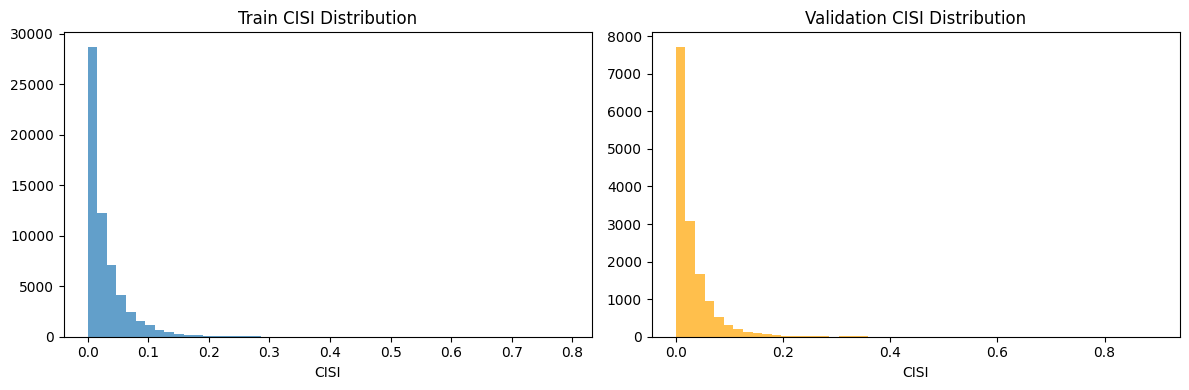

In [22]:
train_targets = []
val_targets = []

for _, target, _ in train_loader:
    train_targets.extend(target.numpy().flatten())

for _, target, _ in val_loader:
    val_targets.extend(target.numpy().flatten())

train_targets = np.array(train_targets)
val_targets = np.array(val_targets)

print("TRAIN SET:")
print(f"  Mean: {train_targets.mean():.4f}, Std: {train_targets.std():.4f}")
print(f"  Range: [{train_targets.min():.4f}, {train_targets.max():.4f}]")

print("\nVAL SET:")
print(f"  Mean: {val_targets.mean():.4f}, Std: {val_targets.std():.4f}")
print(f"  Range: [{val_targets.min():.4f}, {val_targets.max():.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_targets, bins=50, alpha=0.7, label='Train')
axes[0].set_title('Train CISI Distribution')
axes[0].set_xlabel('CISI')

axes[1].hist(val_targets, bins=50, alpha=0.7, label='Val', color='orange')
axes[1].set_title('Validation CISI Distribution')
axes[1].set_xlabel('CISI')

plt.tight_layout()
plt.show()

# Init Model

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

config = {'dropout': 0.3}
model = CNN(config).to(device)
criterion = WeightedMSELoss(threshold=0.2, factor=25)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

Using device: cpu


# Train Model

In [ ]:
# vars
nummber_of_epochs = 50

In [ ]:
train_loss_list, val_loss_list = training(
    num_epochs=nummber_of_epochs,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    clip_value=1.0,
    device=device,
    scheduler=scheduler
)

Epoch [1/50] - Train Loss: 0.0192, Val Loss: 0.0133, LR: 0.000500
Epoch [2/50] - Train Loss: 0.0099, Val Loss: 0.0116, LR: 0.000500
Epoch [3/50] - Train Loss: 0.0097, Val Loss: 0.0127, LR: 0.000498
Epoch [4/50] - Train Loss: 0.0090, Val Loss: 0.0123, LR: 0.000496
Epoch [5/50] - Train Loss: 0.0087, Val Loss: 0.0118, LR: 0.000492
Epoch [6/50] - Train Loss: 0.0085, Val Loss: 0.0112, LR: 0.000488
Epoch [7/50] - Train Loss: 0.0086, Val Loss: 0.0105, LR: 0.000482
Epoch [8/50] - Train Loss: 0.0082, Val Loss: 0.0118, LR: 0.000476
Epoch [9/50] - Train Loss: 0.0081, Val Loss: 0.0125, LR: 0.000469
Epoch [10/50] - Train Loss: 0.0078, Val Loss: 0.0119, LR: 0.000461
Epoch [11/50] - Train Loss: 0.0077, Val Loss: 0.0110, LR: 0.000452
Epoch [12/50] - Train Loss: 0.0079, Val Loss: 0.0116, LR: 0.000443
Epoch [13/50] - Train Loss: 0.0077, Val Loss: 0.0113, LR: 0.000432
Epoch [14/50] - Train Loss: 0.0075, Val Loss: 0.0109, LR: 0.000421
Epoch [15/50] - Train Loss: 0.0077, Val Loss: 0.0112, LR: 0.000410
Epoc

# Plotting some results

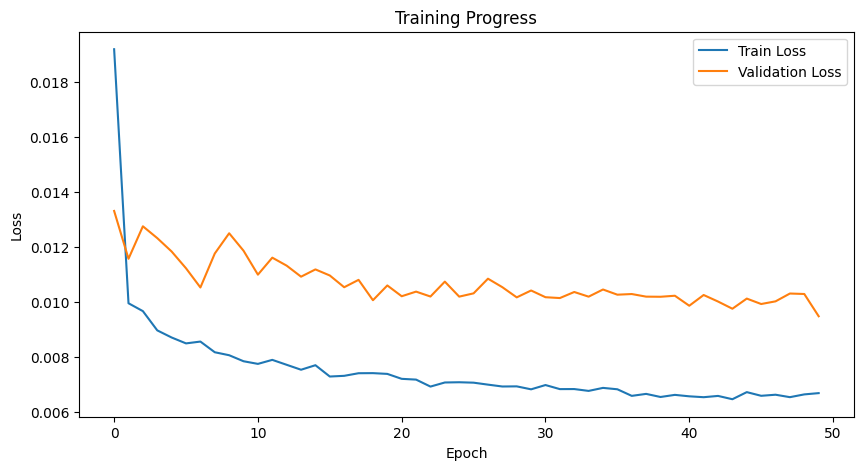

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Progress')
plt.show()

# Full Dataset Evaluation

In [ ]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for batch in val_loader:
        inputs, targets, _ = batch
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.append(outputs.cpu())
        all_targets.append(targets)

preds   = torch.cat(all_preds).numpy().flatten()
targets = torch.cat(all_targets).numpy().flatten()

print(f"Pred range:            {preds.min():.4f} - {preds.max():.4f}")
print(f"Pred mean:             {preds.mean():.4f}  (target mean: {targets.mean():.4f})")
print(f"High CISI pred mean:   {preds[targets > 0.2].mean():.4f}")
print(f"High CISI target mean: {targets[targets > 0.2].mean():.4f}")
print(f"City underprediction:  {(1 - preds[targets>0.2].mean()/targets[targets>0.2].mean())*100:.1f}%")
print(f"\nGlobal R2:  {r2_score(targets, preds):.4f}")
print(f"Global MAE: {mean_absolute_error(targets, preds):.4f}")
print(f"City R2:    {r2_score(targets[targets>0.2], preds[targets>0.2]):.4f}")
print(f"City MAE:   {mean_absolute_error(targets[targets>0.2], preds[targets>0.2]):.4f}")

Pred range:            0.0134 - 0.3390
Pred mean:             0.0497  (target mean: 0.0295)
High CISI pred mean:   0.1401
High CISI target mean: 0.3026
City underprediction:  53.7%

Global R2:  -0.0730
Global MAE: 0.0322
City R2:    -2.3215
City MAE:   0.1676


In [ ]:
# Load best model (Exp102)
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in val_loader:
        inputs, targets, _ = batch
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.append(outputs.cpu())
        all_targets.append(targets)

preds = torch.cat(all_preds).numpy().flatten()
targets = torch.cat(all_targets).numpy().flatten()

# Diagnostics
print(f"Pred range: {preds.min():.4f} - {preds.max():.4f}")
print(f"Pred mean: {preds.mean():.4f}")
print(f"Target mean: {targets.mean():.4f}")
print(f"High CISI pixels (>0.2): {(targets > 0.2).mean()*100:.1f}%")
print(f"High CISI pred mean: {preds[targets > 0.2].mean():.4f}")
print(f"High CISI target mean: {targets[targets > 0.2].mean():.4f}")

Pred range: 0.0134 - 0.3338
Pred mean: 0.0495
Target mean: 0.0295
High CISI pixels (>0.2): 0.8%
High CISI pred mean: 0.1423
High CISI target mean: 0.3026


# Generate predictions

In [ ]:
model.eval()
predictions = []
actuals = []
coordinates = []

with torch.no_grad():
    for batch in val_loader:
        inputs, targets, coords = batch
        inputs = inputs.to(device)
        
        outputs = model(inputs)
        
        predictions.extend(outputs.cpu().numpy().flatten())
        actuals.extend(targets.numpy().flatten())
        coordinates.extend(coords)

predictions = np.array(predictions)
actuals = np.array(actuals)

print(f"Predictions range: [{predictions.min():.3f}, {predictions.max():.3f}]")
print(f"Actuals range: [{actuals.min():.3f}, {actuals.max():.3f}]")

Predictions range: [0.013, 0.351]
Actuals range: [0.000, 0.896]


# Visualize Results

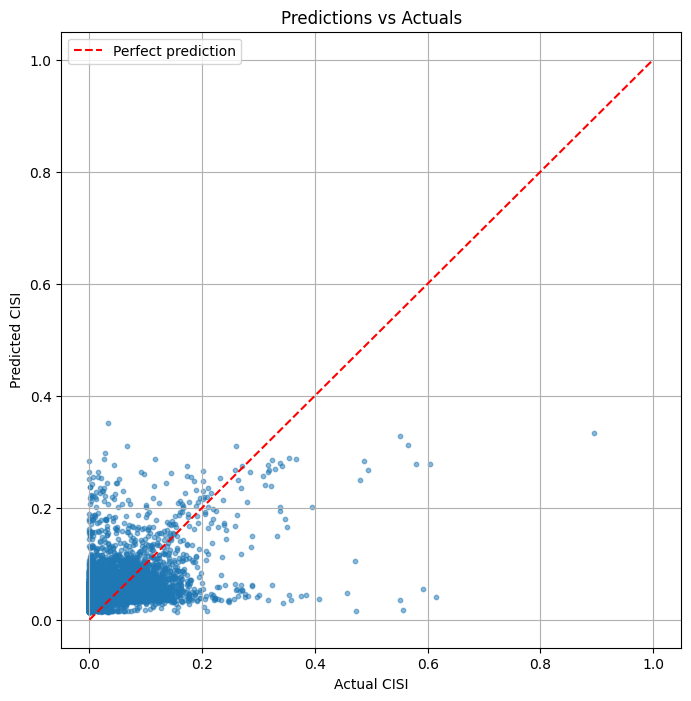

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(actuals, predictions, alpha=0.5, s=10)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
plt.xlabel('Actual CISI')
plt.ylabel('Predicted CISI')
plt.title('Predictions vs Actuals')
plt.legend()
plt.grid(True)
plt.show()

# Metrics

In [ ]:
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actuals, predictions)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"RÂ² Score: {r2:.4f}")

MSE: 0.0018
MAE: 0.0321
RMSE: 0.0424
RÂ² Score: -0.0496


=== ACTUALS ===
Mean: 0.0295
Std: 0.0414
Range: [0.0000, 0.8959]

=== PREDICTIONS ===
Mean: 0.0495
Std: 0.0261
Range: [0.0131, 0.3510]


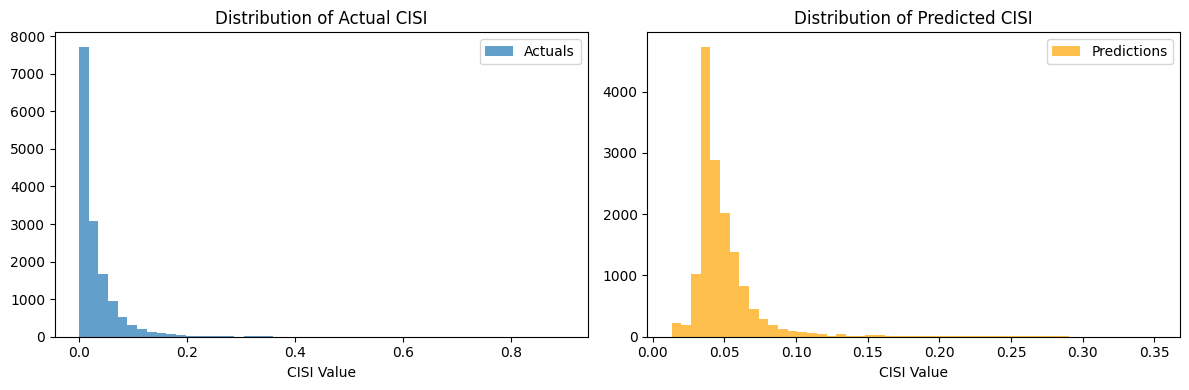

In [ ]:
# Check distributions
print("=== ACTUALS ===")
print(f"Mean: {actuals.mean():.4f}")
print(f"Std: {actuals.std():.4f}")
print(f"Range: [{actuals.min():.4f}, {actuals.max():.4f}]")

print("\n=== PREDICTIONS ===")
print(f"Mean: {predictions.mean():.4f}")
print(f"Std: {predictions.std():.4f}")
print(f"Range: [{predictions.min():.4f}, {predictions.max():.4f}]")

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(actuals, bins=50, alpha=0.7, label='Actuals')
axes[0].set_title('Distribution of Actual CISI')
axes[0].set_xlabel('CISI Value')
axes[0].legend()

axes[1].hist(predictions, bins=50, alpha=0.7, label='Predictions', color='orange')
axes[1].set_title('Distribution of Predicted CISI')
axes[1].set_xlabel('CISI Value')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Look at one sample from dataset
sample_input, sample_target, _ = dataset[0]

print("Input shape:", sample_input.shape)
print("\nInput statistics per channel:")
for i in range(9):
    channel = sample_input[i]
    print(f"Channel {i}: min={channel.min():.2f}, max={channel.max():.2f}, mean={channel.mean():.2f}")

print(f"\nTarget CISI value: {sample_target.item():.4f}")

Input shape: torch.Size([9, 16, 16])

Input statistics per channel:
Channel 0: min=-0.60, max=2.61, mean=0.50
Channel 1: min=0.04, max=1.93, mean=0.84
Channel 2: min=0.00, max=0.00, mean=0.00
Channel 3: min=0.00, max=1.00, mean=0.62
Channel 4: min=0.00, max=1.00, mean=0.29
Channel 5: min=0.00, max=1.00, mean=0.05
Channel 6: min=0.00, max=1.00, mean=0.02
Channel 7: min=0.00, max=1.00, mean=0.01
Channel 8: min=0.00, max=1.00, mean=0.01

Target CISI value: 0.0000


# Generate Predictions on Full Training Set

In [ ]:
# # Generate predictions on ALL training data
# model.eval()
# all_preds = []
# all_actuals = []
# all_indices = []

# with torch.no_grad():
#     for inputs, targets, indices in train_loader:
#         inputs = inputs.to(device)
#         outputs = model(inputs)
        
#         all_preds.extend(outputs.cpu().numpy().flatten())
#         all_actuals.extend(targets.cpu().numpy().flatten())
#         all_indices.extend(indices)

# all_preds = np.array(all_preds)
# all_actuals = np.array(all_actuals)

# # Split by city/rural
# city_mask = all_actuals > 0.1
# rural_mask = all_actuals <= 0.1

# print(f"\n{'='*80}")
# print("TRAINING SET: CITY vs RURAL")
# print(f"{'='*80}")

# print(f"\n CITIES (CISI > 0.1):")
# print(f"  Count: {city_mask.sum():,}")
# print(f"  Actual mean: {all_actuals[city_mask].mean():.4f}")
# print(f"  Pred mean: {all_preds[city_mask].mean():.4f}")
# print(f"  MAE: {mean_absolute_error(all_actuals[city_mask], all_preds[city_mask]):.4f}")

# print(f"\n RURAL (CISI â‰¤ 0.1):")
# print(f"  Count: {rural_mask.sum():,}")
# print(f"  Actual mean: {all_actuals[rural_mask].mean():.4f}")
# print(f"  Pred mean: {all_preds[rural_mask].mean():.4f}")
# print(f"  MAE: {mean_absolute_error(all_actuals[rural_mask], all_preds[rural_mask]):.4f}")

# Save model

In [ ]:
save_model_checkpoint(
    model, optimizer, train_loss_list, val_loss_list, config,
    save_name='exp202',
    dataset=dataset,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    criterion=criterion,
    learning_rate=0.0005,
    batch_size=batch_size,
    num_epochs=nummber_of_epochs,
    patch_size=16
)

# Weights & Biases Hyperparameter Sweep

In [30]:
random.seed(43)  # different seed to avoid same configs as before

param_grid = [
    {
        'lam':     random.choice([15, 20, 25, 30]),
        'lr':      random.uniform(0.0001, 0.001),
        'dropout': random.choice([0.1, 0.2, 0.3]),
    }
    for _ in range(30)
]  

results_path = "hyperparameter_search_results_v2.csv"
print(f"Running {len(param_grid)} configurations...")

Running 30 configurations...


In [31]:
fieldnames = ['lam', 'lr', 'dropout', 'global_r2', 'global_mse', 'global_rmse', 'global_mae',
              'city_r2', 'city_mse', 'city_rmse', 'city_mae', 'city_underprediction',
              'city15_r2', 'city15_mse', 'city15_rmse', 'city15_mae', 'city15_underprediction',
              'pred_max']
best_model_path = "best_search_model.pt"

# Resume: load already-completed runs from CSV
results = []
completed = 0
if os.path.exists(results_path):
    with open(results_path, 'r', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            results.append({k: float(v) for k, v in row.items()})
    completed = len(results)
    print(f"Resuming â€” {completed} runs already done, skipping to run {completed+1}")
else:
    with open(results_path, 'w', newline='') as f:
        csv.DictWriter(f, fieldnames=fieldnames).writeheader()

best_city_underpred = min((r['city_underprediction'] for r in results), default=float('inf'))

for i, params in enumerate(param_grid):
    if i < completed:
        continue

    print(f"\nRun {i+1}/30 â€” lam={params['lam']}, lr={params['lr']:.5f}, dropout={params['dropout']}")

    m = CNN({'dropout': params['dropout']}).to(device)
    crit = WeightedMSELoss(threshold=0.2, factor=params['lam'])
    opt = torch.optim.Adam(m.parameters(), lr=params['lr'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50, eta_min=1e-6)
    es = EarlyStopping(patience=30, delta=0.0001)

    for epoch in range(50):
        m.train()
        for inputs, targets, _ in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            opt.zero_grad()
            loss = crit(m(inputs), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sched.step()

        m.eval()
        val_losses = []
        with torch.no_grad():
            for inputs, targets, _ in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                val_losses.append(crit(m(inputs), targets).item())
        es(np.mean(val_losses))
        if es.early_stop:
            print(f"  Early stop at epoch {epoch+1}")
            break

    m.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, targets, _ in val_loader:
            all_preds.append(m(inputs.to(device)).cpu().numpy())
            all_targets.append(targets.numpy())

    preds   = np.concatenate(all_preds).flatten()
    targets = np.concatenate(all_targets).flatten()
    city_mask   = targets > 0.2
    city15_mask = targets > 0.15

    row = {
        **params,
        'global_r2':             r2_score(targets, preds),
        'global_mse':            mean_squared_error(targets, preds),
        'global_rmse':           np.sqrt(mean_squared_error(targets, preds)),
        'global_mae':            mean_absolute_error(targets, preds),
        'city_r2':               r2_score(targets[city_mask], preds[city_mask]),
        'city_mse':              mean_squared_error(targets[city_mask], preds[city_mask]),
        'city_rmse':             np.sqrt(mean_squared_error(targets[city_mask], preds[city_mask])),
        'city_mae':              mean_absolute_error(targets[city_mask], preds[city_mask]),
        'city_underprediction':  (1 - preds[city_mask].mean() / targets[city_mask].mean()) * 100,
        'city15_r2':             r2_score(targets[city15_mask], preds[city15_mask]),
        'city15_mse':            mean_squared_error(targets[city15_mask], preds[city15_mask]),
        'city15_rmse':           np.sqrt(mean_squared_error(targets[city15_mask], preds[city15_mask])),
        'city15_mae':            mean_absolute_error(targets[city15_mask], preds[city15_mask]),
        'city15_underprediction':(1 - preds[city15_mask].mean() / targets[city15_mask].mean()) * 100,
        'pred_max':              preds.max(),
    }
    results.append(row)

    with open(results_path, 'a', newline='') as f:
        csv.DictWriter(f, fieldnames=fieldnames).writerow(row)

    if row['city_underprediction'] < best_city_underpred:
        best_city_underpred = row['city_underprediction']
        torch.save({'model_state_dict': m.state_dict(), 'params': params}, best_model_path)
        print(f"  *** New best model saved (city_underpred={best_city_underpred:.1f}%)")

    print(f"  Global R2={row['global_r2']:.4f}, City(0.2) underp={row['city_underprediction']:.1f}%, City(0.15) underp={row['city15_underprediction']:.1f}%, Pred max={row['pred_max']:.3f}")

best = min(results, key=lambda x: x['city_underprediction'])
print(f"\nBest: lam={best['lam']}, lr={best['lr']:.5f}, dropout={best['dropout']}")
print(f"  Global R2={best['global_r2']:.4f}, City(0.2) underp={best['city_underprediction']:.1f}%, City(0.15) underp={best['city15_underprediction']:.1f}%")
print(f"  Best model saved to: {best_model_path}")

Resuming â€” 1 runs already done, skipping to run 2

Run 2/30 â€” lam=30, lr=0.00043, dropout=0.3
  *** New best model saved (city_underpred=54.7%)
  Global R2=-0.0076, City(0.2) underp=54.7%, City(0.15) underp=53.4%, Pred max=0.339

Run 3/30 â€” lam=15, lr=0.00051, dropout=0.2
  Early stop at epoch 44
  Global R2=0.1494, City(0.2) underp=55.6%, City(0.15) underp=55.4%, Pred max=0.370

Run 4/30 â€” lam=15, lr=0.00056, dropout=0.3
  Global R2=0.0943, City(0.2) underp=58.7%, City(0.15) underp=57.2%, Pred max=0.307

Run 5/30 â€” lam=25, lr=0.00066, dropout=0.3
  *** New best model saved (city_underpred=51.4%)
  Global R2=-0.1364, City(0.2) underp=51.4%, City(0.15) underp=47.9%, Pred max=0.330

Run 6/30 â€” lam=30, lr=0.00045, dropout=0.1
  Global R2=-0.0136, City(0.2) underp=51.8%, City(0.15) underp=49.5%, Pred max=0.447

Run 7/30 â€” lam=15, lr=0.00084, dropout=0.2
  Early stop at epoch 40
  Global R2=0.1468, City(0.2) underp=57.3%, City(0.15) underp=55.9%, Pred max=0.370

Run 8/30 â€” l

# Debugging checks

In [ ]:
# import torch
# import numpy as np

# print("=" * 70)
# print("CHECKING FIRST BATCH FROM DATALOADER")
# print("=" * 70)

# # Get one batch
# for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#     print(f"\nBatch {batch_idx}:")
#     print(f"  Batch size: {inputs.shape[0]}")
#     print(f"  Input shape: {inputs.shape}")  # Should be (batch, 9, 32, 32)
#     print(f"  Target shape: {targets.shape}")  # Should be (batch, 1)
    
#     # Check for NaN/Inf in inputs
#     print(f"\n  INPUT CHECKS:")
#     print(f"    Contains NaN: {torch.isnan(inputs).any().item()}")
#     print(f"    Contains Inf: {torch.isinf(inputs).any().item()}")
#     print(f"    Min: {inputs.min().item():.4f}")
#     print(f"    Max: {inputs.max().item():.4f}")
#     print(f"    Mean: {inputs.mean().item():.4f}")
    
#     # Check for NaN/Inf in targets
#     print(f"\n  TARGET CHECKS:")
#     print(f"    Contains NaN: {torch.isnan(targets).any().item()}")
#     print(f"    Contains Inf: {torch.isinf(targets).any().item()}")
#     print(f"    Min: {targets.min().item():.4f}")
#     print(f"    Max: {targets.max().item():.4f}")
#     print(f"    Mean: {targets.mean().item():.4f}")
    
#     # Check each channel individually
#     print(f"\n  PER-CHANNEL CHECKS:")
#     channel_names = ['GDP', 'Pop', 'LC_0', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6']
#     for ch in range(9):
#         ch_data = inputs[:, ch, :, :]
#         has_nan = torch.isnan(ch_data).any().item()
#         has_inf = torch.isinf(ch_data).any().item()
#         print(f"    {channel_names[ch]:6s}: min={ch_data.min().item():7.2f}, "
#               f"max={ch_data.max().item():7.2f}, "
#               f"NaN={has_nan}, Inf={has_inf}")
    
#     # Only check first batch
#     break

# print("\n" + "=" * 70)

Total valid non-zero pixels: 78,532
Pixels above 0.15: 1,547 (1.97%)
Pixels above 0.20: 685 (0.87%)
Max CISI: 0.896
Mean CISI: 0.0316


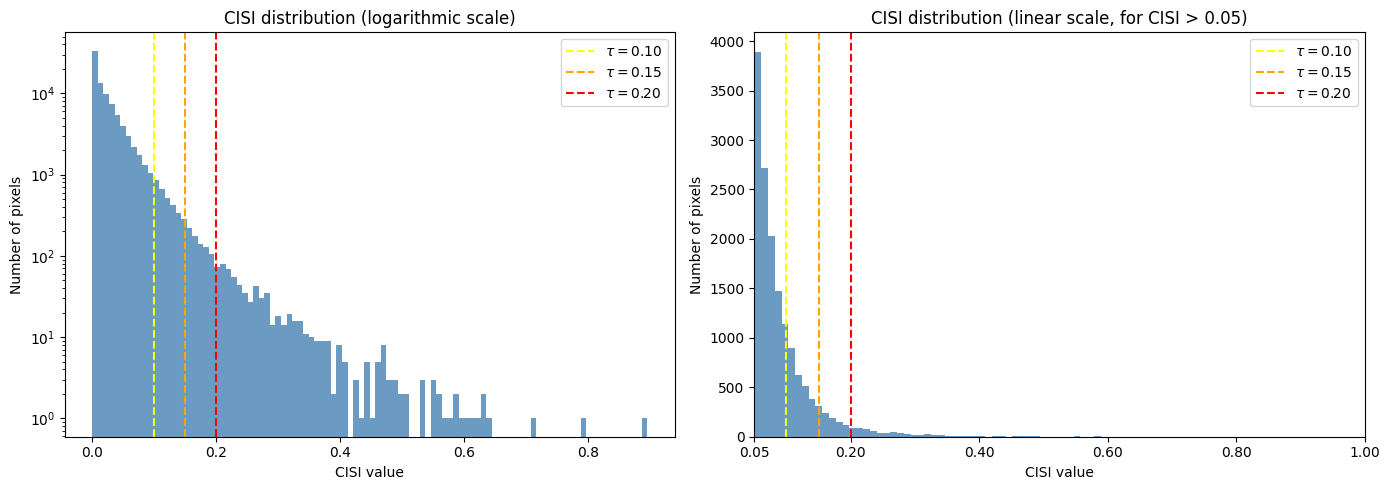

Saved: cisi_distribution.png


: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

cisi_path = r"READY_data\labels\2024_CISI_010deg_nearest.tif"

# Load CISI data 
with rasterio.open(cisi_path) as src:
    cisi_full = src.read(1).astype(np.float32)

# Get valid CISI values only (no NaN, no ocean)
cisi_valid = cisi_full[~np.isnan(cisi_full) & (cisi_full > 0)]

print(f"Total valid non-zero pixels: {len(cisi_valid):,}")
print(f"Pixels above 0.15: {(cisi_valid > 0.15).sum():,} ({100*(cisi_valid > 0.15).mean():.2f}%)")
print(f"Pixels above 0.20: {(cisi_valid > 0.20).sum():,} ({100*(cisi_valid > 0.20).mean():.2f}%)")
print(f"Max CISI: {cisi_valid.max():.3f}")
print(f"Mean CISI: {cisi_valid.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution including zeros
all_valid = cisi_full[~np.isnan(cisi_full)]
axes[0].hist(all_valid, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(0.10, color='yellow', linewidth=1.5, linestyle='--', label=r'$\tau = 0.10$')
axes[0].axvline(0.15, color='orange', linewidth=1.5, linestyle='--', label=r'$\tau = 0.15$')
axes[0].axvline(0.20, color='red',    linewidth=1.5, linestyle='--', label=r'$\tau = 0.20$')
axes[0].set_xlabel('CISI value')
axes[0].set_ylabel('Number of pixels')
axes[0].set_title('CISI distribution (logarithmic scale)')
axes[0].legend()
axes[0].set_yscale('log')

# Right: zoom into the tail (CISI > 0.05) to show the inflection point clearly
tail = cisi_valid[cisi_valid > 0.05]
axes[1].hist(tail, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0.10, color='yellow', linewidth=1.5, linestyle='--', label=r'$\tau = 0.10$')
axes[1].axvline(0.15, color='orange', linewidth=1.5, linestyle='--', label=r'$\tau = 0.15$')
axes[1].axvline(0.20, color='red',    linewidth=1.5, linestyle='--', label=r'$\tau = 0.20$')
axes[1].set_xlim(0.05, 1.0)
axes[1].set_xticks([0.05, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[1].set_xlabel('CISI value')
axes[1].set_ylabel('Number of pixels')
axes[1].set_title('CISI distribution (linear scale, for CISI > 0.05)')
axes[1].legend()

plt.tight_layout()
plt.savefig('cisi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cisi_distribution.png")

In [ ]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import rasterio
import geopandas as gpd
from shapely.geometry import box as shapely_box

with rasterio.open(r'READY_data\inputs\2019_gdp_aligned_010.tif') as s:
    gdp_raw = s.read(1).astype('float32'); b = s.bounds
with rasterio.open(r'READY_data\inputs\2020_pop_aligned_010.tif') as s:
    pop_raw = s.read(1).astype('float32')
with rasterio.open(r'READY_data\landuse_onehot\chen2015_lc_onehot.tif') as s:
    lc_bands = s.read().astype('float32')
with rasterio.open(r'READY_data\labels\eu_mask_010deg.tif') as s:
    eu_mask = s.read(1).astype(bool)

extent = [b.left, b.right, b.bottom, b.top]
XLIM, YLIM = (b.left, b.right), (b.bottom, b.top)

world = gpd.read_file('ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp')
world_clip = world.clip(shapely_box(b.left, b.bottom, b.right, b.top))

def make_cmap(name):
    c = copy.copy(plt.get_cmap(name)); c.set_bad(alpha=0); return c

def eu_only(arr):
    out = arr.copy(); out[~eu_mask] = np.nan; out[out <= 0] = np.nan; return out

gdp_plot = eu_only(gdp_raw)
pop_plot = eu_only(pop_raw)
no_data  = lc_bands.sum(axis=0) == 0
lc_class = (np.argmax(lc_bands, axis=0) + 1).astype('float32')
lc_class[no_data | ~eu_mask] = np.nan

LC_NAMES  = ['Water', 'Cropland', 'Forest', 'Grassland', 'Urban', 'Barren', 'Water bodies']
LC_COLORS = ['#4393c3', '#f4c842', '#1a7e3a', '#a8d08d', '#d62728', '#c9a96e', '#5fa8d3']
lc_cmap   = mcolors.ListedColormap(LC_COLORS); lc_cmap.set_bad(alpha=0)
lc_norm   = mcolors.BoundaryNorm(np.arange(0.5, 8.5), ncolors=7)

LAND_GRAY = '#d4d4d4'; OCEAN = '#c6dff0'; BORDER = '#666666'; BLW = 0.35

def add_basemap(ax):
    ax.set_facecolor(OCEAN)
    world_clip.plot(ax=ax, color=LAND_GRAY, edgecolor='none', zorder=1)

def finish_ax(ax, title):
    world_clip.plot(ax=ax, color='none', edgecolor=BORDER, linewidth=BLW, zorder=4)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect('equal')
    ax.set_title(title, fontsize=10, pad=6)
    ax.set_xlabel('Longitude', fontsize=8); ax.set_ylabel('Latitude', fontsize=8)
    ax.tick_params(labelsize=7)

fig = plt.figure(figsize=(14, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.08, height_ratios=[1, 1])
ax_gdp = fig.add_subplot(gs[0, 0])
ax_pop = fig.add_subplot(gs[0, 1])
ax_lc  = fig.add_subplot(gs[1, :])

add_basemap(ax_gdp)
im1 = ax_gdp.imshow(gdp_plot,
    norm=mcolors.LogNorm(vmin=0.1, vmax=float(np.nanpercentile(gdp_plot, 99))),
    cmap=make_cmap('YlOrRd'), extent=extent, origin='upper', interpolation='nearest', zorder=2)
fig.colorbar(im1, ax=ax_gdp, fraction=0.046, pad=0.04).ax.tick_params(labelsize=8)
finish_ax(ax_gdp, 'GDP per 0.1° cell (M USD 2017 PPP, log scale)')

add_basemap(ax_pop)
im2 = ax_pop.imshow(pop_plot,
    norm=mcolors.LogNorm(vmin=1, vmax=float(np.nanpercentile(pop_plot, 99))),
    cmap=make_cmap('YlGnBu'), extent=extent, origin='upper', interpolation='nearest', zorder=2)
fig.colorbar(im2, ax=ax_pop, fraction=0.046, pad=0.04).ax.tick_params(labelsize=8)
finish_ax(ax_pop, 'Population per 0.1° cell (persons, log scale)')
ax_pop.set_ylabel(''); ax_pop.tick_params(axis='y', labelleft=False)

add_basemap(ax_lc)
ax_lc.imshow(lc_class, norm=lc_norm, cmap=lc_cmap,
    extent=extent, origin='upper', interpolation='nearest', zorder=2)
finish_ax(ax_lc, 'Land cover — dominant class per 0.1° cell (2020 baseline)')
patches = [mpatches.Patch(color=LC_COLORS[i], label=LC_NAMES[i]) for i in range(7)]
ax_lc.legend(handles=patches, loc='center left', bbox_to_anchor=(1.01, 0.5),
             fontsize=9, ncol=1, framealpha=0.9, borderpad=0.8,
             title='Land class', title_fontsize=9)

fig.suptitle('Model input variables — historical baseline (0.1° grid, EU27)',
             fontsize=12, y=1.01)
plt.savefig('figures/input_maps_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')


In [ ]:
# print("=" * 70)
# print("TESTING FORWARD PASS")
# print("=" * 70)

# model.eval()  # Set to eval mode first
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# with torch.no_grad():
#     for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#         inputs = inputs.to(device)
#         targets = targets.to(device).view(-1, 1)
        
#         print(f"\nBatch {batch_idx}:")
#         print(f"  Input device: {inputs.device}")
#         print(f"  Input requires_grad: {inputs.requires_grad}")
        
#         # Forward pass
#         try:
#             outputs = model(inputs)
            
#             print(f"\n  OUTPUT CHECKS:")
#             print(f"    Output shape: {outputs.shape}")
#             print(f"    Contains NaN: {torch.isnan(outputs).any().item()}")
#             print(f"    Contains Inf: {torch.isinf(outputs).any().item()}")
#             print(f"    Min: {outputs.min().item():.4f}")
#             print(f"    Max: {outputs.max().item():.4f}")
#             print(f"    Mean: {outputs.mean().item():.4f}")
            
#             # Compute loss
#             loss = criterion(outputs, targets)
#             print(f"\n  LOSS:")
#             print(f"    Loss value: {loss.item():.4f}")
#             print(f"    Loss is NaN: {torch.isnan(loss).item()}")
#             print(f"    Loss is Inf: {torch.isinf(loss).item()}")
            
#         except Exception as e:
#             print(f"   ERROR during forward pass: {e}")
#             import traceback
#             traceback.print_exc()
        
#         # Only test first batch
#         break

# print("\n" + "=" * 70)

In [ ]:
# print("=" * 70)
# print("DEBUGGING ONE TRAINING STEP")
# print("=" * 70)

# model.train()

# for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#     inputs = inputs.to(device)
#     targets = targets.to(device).view(-1, 1)
    
#     print(f"\n=== STEP {batch_idx} ===")
    
#     # Zero gradients
#     optimizer.zero_grad()
    
#     # Forward
#     print("1. Forward pass...")
#     outputs = model(inputs)
#     print(f"   Outputs: min={outputs.min().item():.4f}, max={outputs.max().item():.4f}, "
#           f"NaN={torch.isnan(outputs).any().item()}")
    
#     # Loss
#     print("2. Computing loss...")
#     loss = criterion(outputs, targets)
#     print(f"   Loss: {loss.item():.4f}, NaN={torch.isnan(loss).item()}")
    
#     if torch.isnan(loss):
#         print("    NaN DETECTED IN LOSS!")
#         print(f"   Sample outputs: {outputs[:5].squeeze()}")
#         print(f"   Sample targets: {targets[:5].squeeze()}")
#         break
    
#     # Backward
#     print("3. Backward pass...")
#     loss.backward()
    
#     # Check gradients
#     print("4. Checking gradients...")
#     total_norm = 0
#     max_grad = 0
#     nan_grads = False
    
#     for name, param in model.named_parameters():
#         if param.grad is not None:
#             grad_norm = param.grad.data.norm(2).item()
#             total_norm += grad_norm ** 2
#             max_grad = max(max_grad, param.grad.abs().max().item())
            
#             if torch.isnan(param.grad).any():
#                 print(f"    NaN gradient in {name}")
#                 nan_grads = True
    
#     total_norm = total_norm ** 0.5
#     print(f"   Total gradient norm: {total_norm:.4f}")
#     print(f"   Max gradient value: {max_grad:.4f}")
    
#     if nan_grads:
#         print("    NaN DETECTED IN GRADIENTS!")
#         break
    
#     if total_norm > 1000:
#         print(f"    WARNING: Very large gradients! (norm={total_norm:.2f})")
    
#     # Clip
#     print("5. Clipping gradients...")
#     torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
#     # Step
#     print("6. Optimizer step...")
#     optimizer.step()
    
#     print("    Step complete\n")
    
#     # Only do 3 steps
#     if batch_idx >= 2:
#         break

# print("\n" + "=" * 70)

In [ ]:
print("=" * 70)
print("CHECKING MODEL WEIGHTS")
print("=" * 70)

print("\nModel parameters:")
for name, param in model.named_parameters():
    print(f"  {name:40s}: shape={str(list(param.shape)):20s} "
          f"mean={param.data.mean().item():8.4f} "
          f"std={param.data.std().item():8.4f} "
          f"NaN={torch.isnan(param.data).any().item()}")

print("\n" + "=" * 70)

CHECKING MODEL WEIGHTS

Model parameters:
  conv_layers.0.weight                    : shape=[16, 9, 3, 3]        mean=  0.0014 std=  0.1171 NaN=False
  conv_layers.0.bias                      : shape=[16]                 mean= -0.0078 std=  0.0733 NaN=False
  conv_layers.1.weight                    : shape=[16]                 mean=  0.9703 std=  0.0592 NaN=False
  conv_layers.1.bias                      : shape=[16]                 mean= -0.2601 std=  0.1435 NaN=False
  conv_layers.5.weight                    : shape=[32, 16, 3, 3]       mean= -0.0030 std=  0.0913 NaN=False
  conv_layers.5.bias                      : shape=[32]                 mean= -0.0030 std=  0.0462 NaN=False
  conv_layers.6.weight                    : shape=[32]                 mean=  0.9888 std=  0.0660 NaN=False
  conv_layers.6.bias                      : shape=[32]                 mean= -0.2024 std=  0.1038 NaN=False
  conv_layers.10.weight                   : shape=[64, 32, 3, 3]       mean= -0.0006 std=  0.0

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_38188\2250598502.py:9: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  f"std={param.data.std().item():8.4f} "


In [ ]:
# Check if 0.1Â° CISI file is correct
with rasterio.open(cisi_path) as src:
    cisi = src.read(1)
    print(f"CISI shape: {cisi.shape}")
    print(f"CISI range: [{np.nanmin(cisi):.4f}, {np.nanmax(cisi):.4f}]")
    print(f"Valid pixels: {(~np.isnan(cisi)).sum():,}")
    print(f"Non-zero CISI: {(cisi > 0).sum():,}")

# Check alignment with GDP
with rasterio.open(gdp_path) as src:
    gdp = src.read(1)
    print(f"\nGDP shape: {gdp.shape}")
    print(f"GDP valid: {(~np.isnan(gdp)).sum():,}")

# Check dataset
print(f"\nDataset valid indices: {len(dataset.valid_indices):,}")

CISI shape: (485, 570)
CISI range: [0.0000, 0.8959]
Valid pixels: 87,346
Non-zero CISI: 78,532

GDP shape: (485, 570)
GDP valid: 89,397

Dataset valid indices: 77,935


In [ ]:
# Check current working directory
print(f"Current directory: {os.getcwd()}")

# List files in current directory
print("\nFiles in current directory:")
for file in Path('.').glob('*.pth'):
    print(f"  {file}")

# Also check common locations
locations_to_check = [
    '.',
    './models',
    '../',
    str(Path.home() / 'Downloads'),
]

print("\nSearching for .pth files...")
for loc in locations_to_check:
    if os.path.exists(loc):
        pth_files = list(Path(loc).glob('**/*.pth'))
        if pth_files:
            print(f"\nFound in {loc}:")
            for f in pth_files:
                print(f"  {f}")

In [ ]:
print(f"Pred min: {predictions.min():.4f}")
print(f"Pred max: {predictions.max():.4f}")
print(f"Actual min: {actuals.min():.4f}")
print(f"Actual max: {actuals.max():.4f}")

Pred min: 0.0650
Pred max: 0.4069
Actual min: 0.0000
Actual max: 0.5846


In [ ]:
with rasterio.open(cisi_path) as src:
    cisi_data = src.read(1)
    print(f"CISI file max: {np.nanmax(cisi_data):.4f}")
    print(f"CISI file 99th percentile: {np.percentile(cisi_data[~np.isnan(cisi_data)], 99):.4f}")